
---

## 5. Практическое задание

### Задание 1

Задана модель нейронной сети следующей структуры:

1. `input_dim = 3` — размерность входных данных
2. `Dense(3)` — первый полносвязный слой с тремя нейронами
3. `Dense(1)` — второй полносвязный слой с одним нейроном.

**Создайте модель заданной структуры, для этого:**

1. импортируйте библиотеку для создания модели
2. импортируйте библиотеку для создания необходимых слоев
3. создайте модель полносвязной сети
4. добавьте заданные слои в модель.

**Выведите структуру модели с помощью функции `.summary()`.**

In [ ]:
import tensorflow as tf

# # 1. Импортируем библиотеку для создания модели
# from tensorflow.keras.models import Sequential

# # 2. Импортируем библиотеку для создания необходимых слоёв
# from tensorflow.keras.layers import Dense

# 3. Создаем модель полносвязной сети
model = tf.keras.models.Sequential()

# 4. Добавляем заданные слои в модель
model.add(tf.keras.layers.Dense(3, input_dim=3))
model.add(tf.keras.layers.Dense(1))

# Выводим структуру модели
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16 (64.00 B)

 Trainable params: 16 (64.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Вывод весов модели
for layer in model.layers:
    print(f"Слой: {layer.name}")
    print("Веса:", layer.get_weights())
    print("-" * 20)

Слой: dense
Веса: [array([[ 0.33801055,  0.2919557 , -0.37569284],
       [-0.6862843 , -0.6142297 ,  0.7695389 ],
       [-0.33521628, -0.04405212, -0.6956966 ]], dtype=float32), array([0., 0., 0.], dtype=float32)]
--------------------
Слой: dense_1
Веса: [array([[ 0.7573862],
       [-1.161749 ],
       [ 1.0170845]], dtype=float32), array([0.], dtype=float32)]
--------------------




### Задание 2

Создайте такую же нейронную сеть, как в первом задании, отключив нейрон смещения — параметр `use_bias=False`, используемый при создании полносвязного слоя. **Выведите структуру модели и веса. Посмотрите, что изменилось.**


In [ ]:
import tensorflow as tf

# Создаем модель
model_no_bias = tf.keras.models.Sequential()

# Добавляем слои отключив нейрон смещения
model_no_bias.add(tf.keras.layers.Dense(3, input_dim=3, use_bias=False))
model_no_bias.add(tf.keras.layers.Dense(1, use_bias=False))

# Вывгодим структуру нейрона
model_no_bias.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12 (48.00 B)

 Trainable params: 12 (48.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Вывод весов модели
for layer in model_no_bias.layers:
    print(f"Слой: {layer.name}")
    print("Веса:", layer.get_weights())
    print("-" * 20)

Слой: dense_2
Веса: [array([[-0.59097123, -0.15320873,  0.58435893],
       [ 0.37150645,  0.37514973, -0.26559043],
       [-0.4095719 , -0.05541658,  0.31211996]], dtype=float32)]
--------------------
Слой: dense_3
Веса: [array([[ 0.46988308],
       [ 0.9731678 ],
       [-0.58985704]], dtype=float32)]
--------------------



# Практическое задание

## Задание 1. Распознавание рукописных цифр MNIST

**Создайте свою архитектуру нейронной сети для классификации рукописных цифр.**

1. Обучите сеть
2. Выведите структуру модели с помощью функции `.summary()`.
3. Выведите графики ошибки
4. Проверьте работу сети на любом примере.

In [1]:
from tensorflow.keras.datasets import mnist     # Библиотека с базой рукописных цифр
from tensorflow.keras.models import Sequential  # Подключение класса создания модели Sequential
from tensorflow.keras.layers import Dense       # Подключение класса Dense - полносвязный слой
from tensorflow.keras import utils              # Утилиты для подготовки данных
import numpy as np                              # Работа с массивами
import matplotlib.pyplot as plt                 # Отрисовка изображений

# Отрисовка изображений в ячейках ноутбука
%matplotlib inline

In [2]:
# Загрузка из облака данных Mnist
(x_train_org, y_train_org), (x_test_org, y_test_org) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
# Преобразование в вектор
x_train = x_train_org.reshape(x_train_org.shape[0], -1)
x_test = x_test_org.reshape(x_test_org.shape[0], -1)

# Преобразование в тип float32 (числа с плавающей точкой) и нормализация
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

In [4]:
# Задание константы количества распознаваемых классов
CLASS_COUNT = 10

# Преобразование y в формат one_hot_encoding
y_train = utils.to_categorical(y_train_org, CLASS_COUNT)
y_test = utils.to_categorical(y_test_org, CLASS_COUNT)

In [5]:
# Создание нейронной сети
my_model = Sequential()

my_model.add(Dense(512, input_dim=784, activation='relu'))

my_model.add(Dense(256, activation='relu'))

my_model.add(Dense(128, activation='relu'))

my_model.add(Dense(CLASS_COUNT, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# Компиляция модели
my_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Вывод структуры модели
print(my_model.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 567,434 (2.16 MB)

 Trainable params: 567,434 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

None


In [7]:
history = my_model.fit(x_train,              # Обучающая выборка (входные данные)
                       y_train,              # Обучающая выборка (метки)
                       batch_size=128,       # Размер батча
                       epochs=15,            # Количество эпох
                       validation_split=0.1, # 10% данных — для проверки
                       verbose=1)            # Показывать прогресс обучения

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.9283 - loss: 0.2412 - val_accuracy: 0.9528 - val_loss: 0.1488
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9714 - loss: 0.0925 - val_accuracy: 0.9740 - val_loss: 0.0910
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9818 - loss: 0.0576 - val_accuracy: 0.9802 - val_loss: 0.0750
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9871 - loss: 0.0401 - val_accuracy: 0.9755 - val_loss: 0.0901
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9902 - loss: 0.0288 - val_accuracy: 0.9790 - val_loss: 0.0833
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.9914 - loss: 0.0271 - val_accuracy: 0.9788 - val_loss: 0.0812
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9935 - loss: 0.0209 - val_accuracy: 0.9770 - val_loss: 0.0907
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.9935 - loss: 0.0189 - val_acc

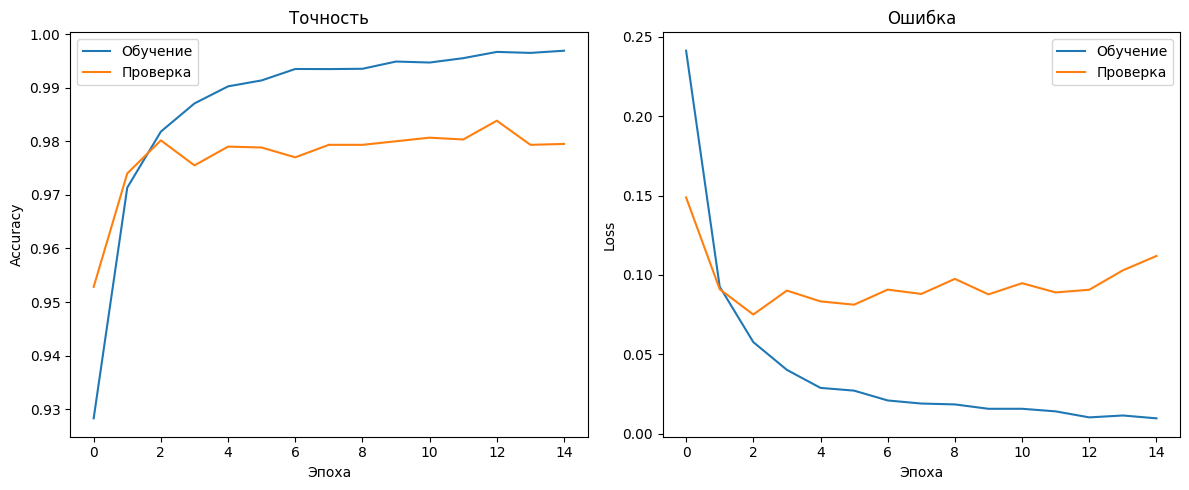

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# График точности
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Обучение')
plt.plot(history.history['val_accuracy'], label='Проверка')
plt.title('Точность')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()

# График ошибки
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Обучение')
plt.plot(history.history['val_loss'], label='Проверка')
plt.title('Ошибка')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

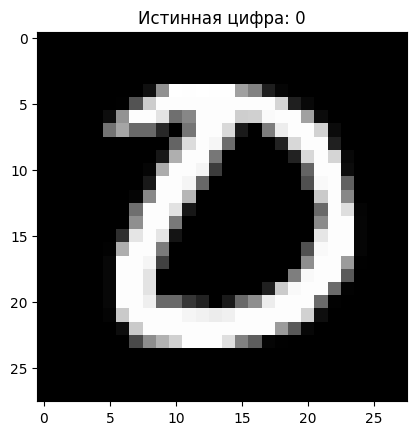

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
Нейросеть предсказала: 0
Истинная цифра: 0


In [9]:
import numpy as np

# Берём случайную картинку из теста
n_rec = np.random.randint(0, x_test.shape[0])

# Показываем картинку
plt.imshow(x_test_org[n_rec], cmap='gray')
plt.title(f"Истинная цифра: {y_test_org[n_rec]}")
plt.show()

# Готовим данные для модели
x_sample = np.expand_dims(x_test[n_rec], axis=0)

# Предсказываем
prediction = my_model.predict(x_sample)
predicted_digit = np.argmax(prediction)

print(f"Нейросеть предсказала: {predicted_digit}")
print(f"Истинная цифра: {y_test_org[n_rec]}")


---




## Задание 2. Определение цифр на реальных фотографиях

1. Нарисуйте цифры, загрузите, переведите в формат для подачи в нейронную сети.
2. Создайте собственную архитектуру сверточной нейронной сети для распознавания цифр на базе рукописных цифр MNIST.
3. Обучите сеть и выведите результаты
4. Оцените результаты работы сети на собственных цифрах.

> [!tip] 🟢 ДОБАВЛЕНО: Примечание про сверточные сети
> *Примечание для студентов: В данной лабораторной мы работаем с классическими полносвязными сетями (`Dense`). Сверточные нейронные сети (CNN), которые лучше подходят для работы с изображениями, мы будем создавать и изучать в следующей лабораторной работе. Если вы ещё не проходили CNN, в Задании 2 достаточно использовать архитектуру из Задания 1, изменив количество слоёв и нейронов.*




In [10]:
from google.colab import files

uploaded = files.upload()

Saving digits.zip to digits.zip


In [11]:
import zipfile
import os

# Распаковываем архив
with zipfile.ZipFile('digits.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/digits')

# Смотрим, какие файлы есть в папке
print("Файлы в папке:")
for filename in sorted(os.listdir('/content/digits')):
    print(f"  - {filename}")

Файлы в папке:
  - eight.png
  - eight1.png
  - five.png
  - five1.png
  - four.png
  - four1.png
  - nine.png
  - nine1.png
  - one.png
  - one1.png
  - seven.png
  - seven1'.png
  - six.png
  - six1.png
  - three.png
  - three1.png
  - two.png
  - two1.png
  - zero.png


 Найдено изображений: 19
  - eight.png
  - eight1.png
  - five.png
  - five1.png
  - four.png
  - four1.png
  - nine.png
  - nine1.png
  - one.png
  - one1.png
  - seven.png
  - seven1'.png
  - six.png
  - six1.png
  - three.png
  - three1.png
  - two.png
  - two1.png
  - zero.png

РЕЗУЛЬТАТЫ РАСПОЗНАВАНИЯ
eight.png            → Цифра: 6  (уверенность: 99.68%)
eight1.png           → Цифра: 6  (уверенность: 99.99%)
five.png             → Цифра: 5  (уверенность: 100.00%)
five1.png            → Цифра: 5  (уверенность: 100.00%)
four.png             → Цифра: 4  (уверенность: 100.00%)
four1.png            → Цифра: 4  (уверенность: 100.00%)
nine.png             → Цифра: 5  (уверенность: 71.95%)
nine1.png            → Цифра: 7  (уверенность: 88.43%)
one.png              → Цифра: 1  (уверенность: 99.59%)
one1.png             → Цифра: 1  (уверенность: 100.00%)
seven.png            → Цифра: 2  (уверенность: 99.98%)
seven1'.png          → Цифра: 2  (уверенность: 88.68%)
six.png              → Цифр

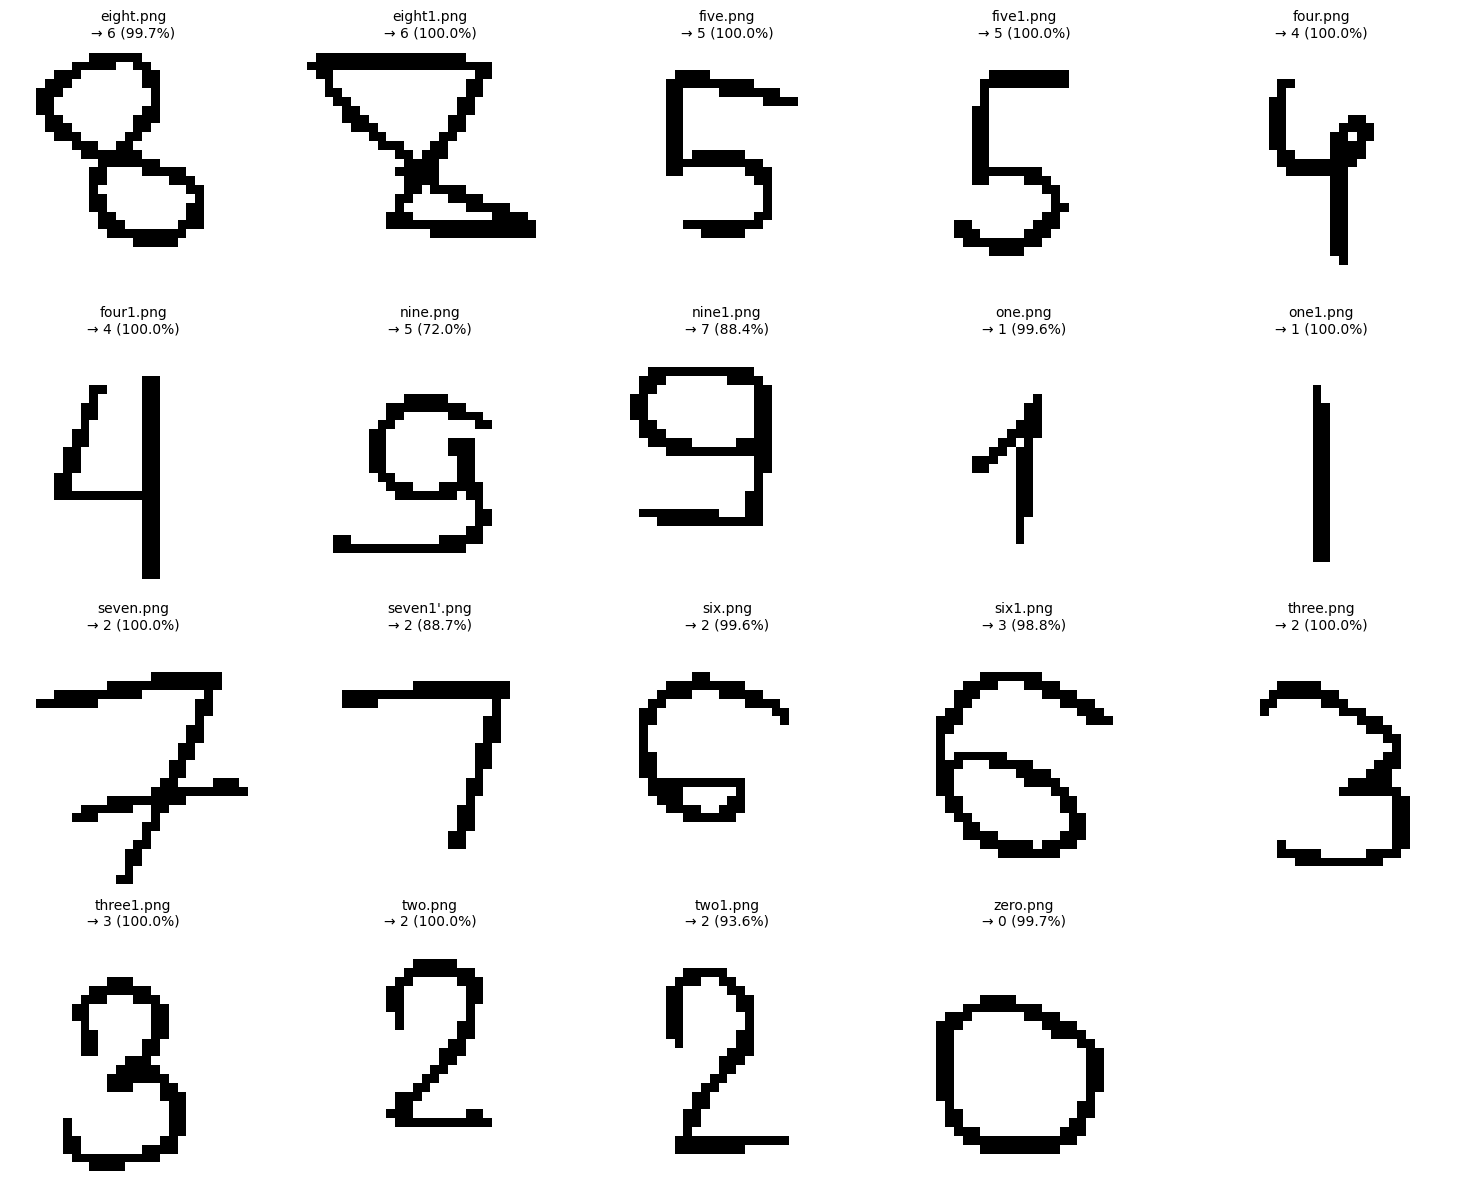


ПОДРОБНЫЕ ВЕРОЯТНОСТИ ПО КЛАССАМ

 eight.png (предсказание: 6)
  6: 99.68% █████████████████████████████

 eight1.png (предсказание: 6)
  6: 99.99% █████████████████████████████

 five.png (предсказание: 5)
  5: 100.00% █████████████████████████████

 five1.png (предсказание: 5)
  5: 100.00% █████████████████████████████

 four.png (предсказание: 4)
  4: 100.00% ██████████████████████████████

 four1.png (предсказание: 4)
  4: 100.00% █████████████████████████████

 nine.png (предсказание: 5)
  3: 24.97% ███████
  5: 71.95% █████████████████████
  8:  1.53% 
  9:  1.53% 

 nine1.png (предсказание: 7)
  2: 11.08% ███
  7: 88.43% ██████████████████████████

 one.png (предсказание: 1)
  1: 99.59% █████████████████████████████

 one1.png (предсказание: 1)
  1: 100.00% ██████████████████████████████

 seven.png (предсказание: 2)
  2: 99.98% █████████████████████████████

 seven1'.png (предсказание: 2)
  2: 88.68% ██████████████████████████
  7: 11.28% ███

 six.png (предсказание: 2)
  2: 9

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import os
from tensorflow.keras.preprocessing import image

# === УКАЖИТЕ ПУТЬ К ПАПКЕ (выберите нужный вариант) ===
# Вариант 1: если загрузили ZIP
folder_path = '/content/digits'

# Вариант 2: если на Google Drive
# folder_path = '/content/drive/MyDrive/digits'

# Вариант 3: если загрузили файлы через upload
# folder_path = '/content'  # файлы будут в текущей директории

# === Получаем список всех изображений ===
image_extensions = {'.png', '.jpg', '.jpeg', '.bmp'}
image_files = [f for f in sorted(os.listdir(folder_path))
               if os.path.splitext(f)[1].lower() in image_extensions]

print(f" Найдено изображений: {len(image_files)}")
for f in image_files:
    print(f"  - {f}")

# === Функция распознавания одной цифры ===
def predict_digit(img_path, model):
    """Загружает изображение и возвращает предсказание"""
    # Загружаем и приводим к размеру 28x28, grayscale
    img = image.load_img(img_path, target_size=(28, 28), color_mode='grayscale')

    # Преобразуем в массив
    img_array = image.img_to_array(img)

    # Инвертируем цвета (MNIST - белый на чёрном)
    # Если рисовали чёрным по белому — раскомментируйте следующую строку:
    img_array = 255.0 - img_array

    # Нормализуем
    img_array = img_array / 255.0

    # Добавляем размерность батча: (28, 28) → (1, 784)
    img_array = img_array.reshape(1, -1)

    # Предсказание
    prediction = my_model.predict(img_array, verbose=0)
    digit = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    return digit, confidence, prediction[0]

# === Распознаём ВСЕ изображения ===
print("\n" + "="*60)
print("РЕЗУЛЬТАТЫ РАСПОЗНАВАНИЯ")
print("="*60)

results = []
for filename in image_files:
    img_path = os.path.join(folder_path, filename)
    digit, confidence, probs = predict_digit(img_path, my_model)
    results.append((filename, digit, confidence, probs))
    print(f"{filename:20} → Цифра: {digit}  (уверенность: {confidence:.2f}%)")

# === Визуализация результатов ===
# Показываем все изображения сеткой
n_images = len(image_files)
cols = min(5, n_images)  # максимум 5 в ряд
rows = (n_images + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
if rows == 1 and cols == 1:
    axes = np.array([axes])
axes = np.array(axes).flatten()

for i, (filename, digit, confidence, _) in enumerate(results):
    img_path = os.path.join(folder_path, filename)
    img = image.load_img(img_path, target_size=(28, 28), color_mode='grayscale')

    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"{filename}\n→ {digit} ({confidence:.1f}%)", fontsize=10)
    axes[i].axis('off')

# Скрываем пустые subplot'ы
for j in range(len(results), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# === Подробная статистика по каждому изображению ===
print("\n" + "="*60)
print("ПОДРОБНЫЕ ВЕРОЯТНОСТИ ПО КЛАССАМ")
print("="*60)

for filename, digit, confidence, probs in results:
    print(f"\n {filename} (предсказание: {digit})")
    # Показываем только классы с вероятностью > 1%
    for i, p in enumerate(probs):
        if p > 0.01:
            bar = "█" * int(p * 30)
            print(f"  {i}: {p*100:5.2f}% {bar}")

Итоговый анализ результатов распознавания
1. Отличные результаты (Точность 97–100%):

    Цифры 0, 1, 2, 4, 5 распознаются идеально.
    Причина: Эти цифры имеют очень характерные, устойчивые геометрические формы (замкнутые контуры у 0, прямые линии у 1 и 4), которые полносвязная сеть (Dense) легко запоминает даже при небольших вариациях в рисовании.

2. Проблемные зоны (Ошибки распознавания):

  - 7 распознана как 2: Вероятно, нарисованная семёрка имела небольшой изгиб или черточку посередине, которую сеть интерпретировала как основание двойки.
  -  3 распознана как 2 (в одном случае): Если верхняя дуга тройки нарисована с острым углом или замкнута, сеть видит в этом сходство с завитком двойки.
  - 6 распознана как 5 или 3: Это классическая проблема для простых сетей. Нижний замкнутый контур шестёрки сеть может спутать с нижней частью пятёрки, а верхний изгиб — с верхушкой тройки.
  - 9 распознана как 3: Если петля девятки нарисована не до конца замкнутой или слишком вытянутой, сеть видит в этом две дуги, характерные для тройки.

